# Setup Instructions
- Create a shortcut to the dataset into your MyDrive folder.
  - Open the shared folder from discord
  - click on the 3 dots
  - click on organise
  - Click Add shortcut
  - Click all locations tab
  - Click My Drive
  - Click Add
  - Then try running the below cell, you will need to login to google or whatever (per session)
  - It'll take a minute to run, if it runs without issues, great!!
- Additionally, run this import stuff only once per session (or everytime you need to reload it)

**NOTE**: Please shortcut the SeniorDesign Folder, not the dataset

In [ ]:
!pip install captum scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 5.4 MB/s eta 0:00:00


In [ ]:
from captum.attr import IntegratedGradients

In [ ]:
# Loading the code
from numpy import load
import numpy as np

from google.colab import drive
drive.mount('/content/drive')
#The above lines are run only once per session I think


path = 'drive/MyDrive/SeniorDesign/integrated_eeg_dataset.npz'

loaded = load(path)
X_raw = loaded['X_raw'].astype(np.float32)
y_labels = loaded['y_labels']
X_features = loaded['X_features']
loaded.close()

Mounted at /content/drive


In [ ]:
print("--- X_raw (Raw EEG signals) ---")
# Expected: "(101916, 128, 19)"
print(f"  Shape: {X_raw.shape} = (samples, time_points, channels)")
# Expected: "float32"
print(f"  dtype: {X_raw.dtype}")

# These are hardcoded in (I forgot why, we can delete it though later)
print(f"  Channels: 19 EEG electrodes")
print(f"  Time points: 128 per sample")

--- X_raw (Raw EEG signals) ---
  Shape: (101916, 128, 19) = (samples, time_points, channels)
  dtype: float32
  Channels: 19 EEG electrodes
  Time points: 128 per sample


In [ ]:
print("=== EEG Alzheimer Dataset Overview ===\n")

print(f"Total samples: {X_raw.shape[0]}")
print(f"Keys: {list(loaded.files)}\n")
loaded.close()

=== EEG Alzheimer Dataset Overview ===

Total samples: 101916
Keys: ['X_raw', 'y_labels', 'X_features']



In [ ]:
print("\n--- y_labels (Sample metadata) ---")
print(f"  Shape: {y_labels.shape}")
print(f"  Columns: {y_labels[0]}")
print(f"  Unique diagnoses: {np.unique(y_labels[:, 2])}")


--- y_labels (Sample metadata) ---
  Shape: (101916, 3)
  Columns: ['0' '10' 'AD-Auditory']
  Unique diagnoses: ['AD-Auditory' 'ADFSU' 'ADFTD' 'ADSZ' 'APAVA-19']


In [ ]:
print("\n--- X_features (Extracted features) ---")
print(f"  Shape: {X_features.shape} = (samples, features)")
print(f"  dtype: {X_features.dtype}")
for i in range(3):
  print(X_features[i])


--- X_features (Extracted features) ---
  Shape: (101916, 76) = (samples, features)
  dtype: float64
[  1.82015021   2.50509275   2.25809061   1.50167282   0.32300244
  -0.53848604  -0.27820251   0.06857888  -0.24109106  -0.67665319
  -0.88558893  -0.81363908  -0.62182606  -0.88484203  -0.28989848
  -0.81453105  -0.82686595  -0.70887044  -0.89609355   6.05250409
   5.74225884   6.07360047   5.28518621   3.28890046   4.40968782
   4.53335161   3.44932797   2.42963621   1.75727217   2.61971746
   2.76257964   3.25077099   2.53414532   3.87664675   2.74008685
   3.10859715   3.3173598    2.72353113  -8.8561697   -8.67520046
  -9.60211372 -12.06108093  -5.91496897 -14.10529518 -12.65802479
 -11.87481785  -7.05524731  -4.42977858  -7.5743022   -7.15479183
 -10.71731377  -6.99979544  -9.38653469  -8.01878548  -9.08146286
  -9.11649895  -8.6043005   24.89109421  26.66282463  18.05597878
  14.30289078   9.52883625   9.71961689   7.82721949   8.92128468
   6.84275484   5.23631191   4.32512712 

In [ ]:
for i in range(3):
  print(X_raw[i])

[[ 0.16900116 -1.268384   -4.1718144  ...  0.3510189  -0.27065784
   0.05400842]
 [-5.5549083  -6.2311134  -3.328059   ...  1.7101046   3.4119506
   3.1785455 ]
 [-3.7924392  -2.4721043   5.008101   ...  1.443295    2.405137
   1.9562126 ]
 ...
 [ 6.9021196  -0.6584709   8.653987   ... -4.2834244  -1.8824382
  -2.4290843 ]
 [ 7.567824   -2.0001578  17.175917   ... -5.590732   -1.7081133
  -4.2626915 ]
 [ 5.597966   -1.2163658   8.174268   ... -2.9905152  -1.5416573
  -3.2431736 ]]
[[-1.8993657  -3.4388037   0.5883852  ...  3.4845347  -1.8261514
  -1.2492489 ]
 [-0.70299715  2.9044638  -2.115847   ...  0.16033465 -3.232751
  -3.782267  ]
 [ 1.1899402   1.3456907  -2.452975   ...  1.2999321  -1.3115041
  -1.963543  ]
 ...
 [-4.210558    5.72008    -6.0956616  ...  1.5845385  -0.8802273
  -2.1842315 ]
 [-4.530818    5.4080443  -7.1501365  ...  1.0682247  -1.8020787
  -3.0616207 ]
 [-7.15052     4.9581876  -7.856224   ...  4.275958    3.4350064
   1.6372496 ]]
[[-0.69341654 -4.344174    4.

In [ ]:
print("\n--- Sample breakdown ---")
for label in np.unique(y_labels[:, 0]):
    count = np.sum(y_labels[:, 0] == label)
    print(f"  {label}: {count} samples ({100*count/len(y_labels):.1f}%)")


--- Sample breakdown ---
  -1: 1179 samples (1.2%)
  0: 31892 samples (31.3%)
  0.0: 1809 samples (1.8%)
  1: 26056 samples (25.6%)
  1.0: 2547 samples (2.5%)
  2: 38433 samples (37.7%)


In [ ]:
for i in y_labels:
  i[0] = int(i[0].split(".")[0]) # Take the weirdly-mapped label and convert it to a proper integer
  i[1] = int(i[1].split(".")[0]) # Take the weirdly-mapped label and convert it to a proper integer
print("\n--- Sample breakdown ---")
# This mapping is based on the data card we got on Kaggle
mapping = ["Unknown/Excluded/Unlabeled","Healthy Control (HC)","Alzheimer's Disease (AD)","Other Dementia/FTD"]
for label in np.unique(y_labels[:, 0]):
    count = np.sum(y_labels[:, 0] == label)
    convertedLabelInt = int(label)
    mappedTextLabel = mapping[convertedLabelInt + 1] # We are adding one since the label starts at -1 (for excluded)
    print(f"  {mappedTextLabel}: {count} samples ({100*count/len(y_labels):.1f}%)")
print("Total samples: " , y_labels.size)



--- Sample breakdown ---
  Unknown/Excluded/Unlabeled: 1179 samples (1.2%)
  Healthy Control (HC): 33701 samples (33.1%)
  Alzheimer's Disease (AD): 28603 samples (28.1%)
  Other Dementia/FTD: 38433 samples (37.7%)
Total samples:  305748


In [ ]:
# Reload the dataset to restore y_labels
loaded = load(path)
X_raw = loaded['X_raw'].astype(np.float32)
y_labels = loaded['y_labels']
X_features = loaded['X_features']
loaded.close()

# Helper function to clean label (remove .0 if present) and return integer
def get_clean_label(val):
    return int(val.split('.')[0])

# Map labels to integers for comparison
# Based on previous context: 0=Healthy, 1=AD
cleaned_labels = np.array([get_clean_label(x) for x in y_labels[:, 0]])

X_raw = X_raw[(cleaned_labels > -1) & (cleaned_labels < 3)]
y_labels = y_labels[(cleaned_labels > -1) & (cleaned_labels < 3)]
cleaned_labels = cleaned_labels[(cleaned_labels > -1) & (cleaned_labels < 3)]

# Filter for Alzheimer's Disease (Label 1) and Healthy Controls (Label 0)
ad_indices = cleaned_labels == 1
healthy_indices = cleaned_labels == 0

# Extract subject IDs for these indices
# We also need to clean the subject IDs to avoid duplicates like '10' and '10.0'
ad_subject_ids_raw = y_labels[ad_indices, 1]
healthy_subject_ids_raw = y_labels[healthy_indices, 1]
all_subject_ids_raw = np.concatenate((ad_subject_ids_raw, healthy_subject_ids_raw))

ad_subject_ids = np.array([int(x.split('.')[0]) for x in ad_subject_ids_raw])
healthy_subject_ids = np.array([int(x.split('.')[0]) for x in healthy_subject_ids_raw])
all_subject_ids = np.array([int(x.split('.')[0]) for x in all_subject_ids_raw])
all_unique_subject_ids = np.unique(all_subject_ids)
# Count unique subjects for AD
unique_ad_subjects = np.unique(ad_subject_ids)
print(f"Number of unique subjects with Alzheimer's Disease: {len(unique_ad_subjects)}")
print(f"Subject IDs (AD): {unique_ad_subjects}")

# Count unique subjects for Healthy Controls
unique_healthy_subjects = np.unique(healthy_subject_ids)
print(f"\nNumber of unique Healthy Control subjects: {len(unique_healthy_subjects)}")
print(f"Subject IDs (Healthy): {unique_healthy_subjects}")

# Find items in unique_healthy_subjects but not in unique_ad_subjects
only_healthy_subjects = []
for subject in unique_healthy_subjects:
    if subject not in unique_ad_subjects:
        only_healthy_subjects.append(int(subject))

print(f"\nSubjects only in Healthy group (not in AD): {len(only_healthy_subjects)}")
print(f"Subject IDs (Only Healthy): {only_healthy_subjects}")

print("\nTotal subjects: ", len(all_unique_subject_ids))

In [ ]:
counter = 0
for i in range(len(y_labels)):
  if(y_labels[i][1] == "10"):
    counter = counter + 1
print(counter)

In [ ]:
# Setup Torch
# !pip3 uninstall --yes torch torchaudio torchvision torchtext torchdata
!pip3 install torch torchaudio torchvision torchtext torchdata

In [ ]:
!pip install pytorch_tcn

In [ ]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pytorch_tcn import TCN

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

In [ ]:
tcn_model = TCN(
    num_inputs=19,
    num_channels=[128],
    kernel_size=4,
    dilations=None,
    dilation_reset=None,
    dropout = 0.1,
    causal=True,
    use_norm = 'weight_norm',
    activation = 'relu',
    kernel_initializer = 'xavier_uniform',
    use_skip_connections = False,
    input_shape = 'NCL',
    embedding_shapes = None,
    embedding_mode = 'add',
    use_gate = False,
    lookahead = 0,
    output_projection = None,
    output_activation = None,
)

In [ ]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.tcn = tcn_model
    self.linear = nn.Linear(19, 1)

  def forward(self, x):
    tcn_out = self.tcn(x)
    linear_out = self.linear(tcn_out)
    return linear_out

## Data Preparation


Prepare the data for every classifier by encoding labels, reshaping inputs, and creating DataLoaders.


importing
 libraries, encoding labels, reshaping data, converting to tensors, splitting the dataset, and creating DataLoaders.



In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset

# 1 Clean labels

# 2. Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(cleaned_labels)
print("Classes mapping:", dict(enumerate(le.classes_)))

# 3. Transpose X_raw (Samples, Time, Channels) -> (Samples, Channels, Time)
X_transposed = np.transpose(X_raw, (0, 2, 1))
print(f"Original shape: {X_raw.shape}")
print(f"Transposed shape: {X_transposed.shape}")

np.savetxt("drive/MyDrive/SeniorDesign/data.csv", X_raw[0], delimiter=",")

# 4. Convert to PyTorch tensors
X_tensor = torch.tensor(X_transposed, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

# 5. Split into training and testing sets
# Using stratify to maintain class distribution is recommended given the imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# 6. Create DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("DataLoaders created successfully.")

## Define TCN Classifier

Define and instantiate the Neural Network model incorporating the TCN layer and a final classification head.


In [ ]:
import subprocess
import sys

# Install pytorch_tcn explicitly since it was missing
subprocess.check_call([sys.executable, "-m", "pip", "install", "pytorch_tcn"])

import torch
import torch.nn as nn
from pytorch_tcn import TCN

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        # Initialize TCN with specified parameters
        self.tcn = TCN(
            num_inputs=19,
            num_channels=[128, 64, 64, 32, 32, 16],
            kernel_size=31,
            dropout=0.1,
            causal=False,
            input_shape='NCL',
            activation='relu'
        )
        self.linear = nn.Linear(16,3)

    def forward(self, x):
        # Pass input through TCN
        tcn_out = self.tcn(x)
        # return tcn_out[:, :, -1]
        # Extract the output of the last time step
        # Shape: (Batch, Channels, Time) -> (Batch, Channels)
        last_step_out = tcn_out[:, :, -1]
        # Pass through linear layer
        logits = self.linear(last_step_out)
        return logits

# Instantiate the model and move to device
model = NeuralNetwork().to(device)
print(model)

Using device: cuda
NeuralNetwork(
  (tcn): TCN(
    (network): ModuleList(
      (0): TemporalBlock(
        (conv1): ParametrizedTemporalConv1d(
          19, 128, kernel_size=(31,), stride=(1,)
          (padder): TemporalPad1d(
            (pad): ConstantPad1d(padding=(15, 15), value=0.0)
          )
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
        (conv2): ParametrizedTemporalConv1d(
          128, 128, kernel_size=(31,), stride=(1,)
          (padder): TemporalPad1d(
            (pad): ConstantPad1d(padding=(15, 15), value=0.0)
          )
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
        (activation1): ReLU()
        (activation2): ReLU()
        (activation_final): ReLU()
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, in


* Redo the data splitting using `X_transposed` and `y_encoded` to create Training (70%), Validation (15%), and Test (15%) sets with stratified sampling, and create PyTorch DataLoaders for each.
* Helper function to calculate F1 score, Precision, Recall, and weighted Specificity.

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch

# 1. First split: 70% Train, 30% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_transposed, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

# 2. Second split: Split Temp equally into Val (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# 3. Convert to PyTorch tensors
# Features to float32
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Labels to long
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 4. Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 5. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 6. Print dataset sizes
print(f"Training set: {len(train_dataset)} samples")
print(f"Validation set: {len(val_dataset)} samples")
print(f"Test set: {len(test_dataset)} samples")

Training set: 70515 samples
Validation set: 15111 samples
Test set: 15111 samples


## Define Metrics and Re-initialize Model


## Train with Validation and Final Evaluation

* Re-instantiate the TCN model and optimizer to reset weights, then train for 5 epochs, printing validation loss and accuracy at each epoch.
* Report the evaluation metrics for the Training, Validation, and Test sets.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import numpy as np

def calculate_metrics(y_true, y_pred):
    """
    Calculates weighted F1, Precision, Recall, and Specificity.
    """
    # Precision, Recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    # Weighted Specificity
    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]
    specificities = []
    supports = np.sum(cm, axis=1)

    for i in range(n_classes):
        # TN for class i: All samples that are NOT class i (Total)
        # minus those predicted as i (FP + TP) ... wait, simpler:
        # TN_i: Actual non-i correctly predicted as non-i.
        # TN = Total - Row_i - Col_i + Diag_i

        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]

        # Specificity = TN / (TN + FP)
        denom = tn + fp
        if denom > 0:
            spec = tn / denom
        else:
            spec = 0.0
        specificities.append(spec)

    weighted_specificity = np.average(specificities, weights=supports)

    return {
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'specificity': weighted_specificity
    }

# Re-instantiate model, optimizer, and criterion
device = "cuda" if torch.cuda.is_available() else "cpu"
# Using the previously defined NeuralNetwork class
model = NeuralNetwork().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Metrics function defined.")
print("Model, optimizer, and criterion re-initialized.")


# Helper function to generate predictions for an entire loader
def get_predictions(loader, model, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)

num_epochs = 20
print(f"Starting training on {device}...")

# 1. Training Loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        # before = model.linear.weight.clone()
        optimizer.step()
        # after = model.linear.weight
        # print(f"Weight changed: {not torch.equal(before, after)}")

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Validation step
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

# 2. Final Evaluation on all sets
print("\nTraining complete. Calculating final metrics on all datasets...")

loaders = {
    "Training": train_loader,
    "Validation": val_loader,
    "Test": test_loader
}

for name, loader in loaders.items():
    y_true, y_pred = get_predictions(loader, model, device)

    # Calculate metrics
    metrics = calculate_metrics(y_true, y_pred)
    # Basic accuracy
    accuracy = np.mean(y_true == y_pred) * 100

    print(f"\n--- {name} Set Metrics ---")
    print(f"Accuracy:    {accuracy:.2f}%")
    print(f"F1 Score:    {metrics['f1']:.4f}")
    print(f"Precision:   {metrics['precision']:.4f}")
    print(f"Recall:      {metrics['recall']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    if name == "Test":
      tcn_metrics = metrics

Metrics function defined.
Model, optimizer, and criterion re-initialized.
Starting training on cuda...
Epoch [1/20] Train Loss: 1.0302 | Val Loss: 0.9217 | Val Acc: 50.00%
Epoch [2/20] Train Loss: 0.8858 | Val Loss: 0.7959 | Val Acc: 56.26%
Epoch [3/20] Train Loss: 0.7613 | Val Loss: 0.7285 | Val Acc: 58.73%
Epoch [4/20] Train Loss: 0.7492 | Val Loss: 0.7314 | Val Acc: 58.87%
Epoch [5/20] Train Loss: 0.7206 | Val Loss: 0.7218 | Val Acc: 58.57%
Epoch [6/20] Train Loss: 0.7081 | Val Loss: 0.7188 | Val Acc: 59.06%
Epoch [7/20] Train Loss: 0.7277 | Val Loss: 0.7115 | Val Acc: 59.47%
Epoch [8/20] Train Loss: 0.7042 | Val Loss: 0.7031 | Val Acc: 59.74%
Epoch [9/20] Train Loss: 0.7191 | Val Loss: 0.7013 | Val Acc: 59.85%
Epoch [10/20] Train Loss: 0.7013 | Val Loss: 0.7073 | Val Acc: 59.64%
Epoch [11/20] Train Loss: 0.7098 | Val Loss: 0.7032 | Val Acc: 59.70%
Epoch [12/20] Train Loss: 0.6960 | Val Loss: 0.6975 | Val Acc: 59.88%
Epoch [13/20] Train Loss: 0.6987 | Val Loss: 0.7057 | Val Acc: 59.

Export our flagship model:

In [ ]:
!pip install onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 19.3 MB/s eta 0:00:00


In [ ]:
# import torch.onnx as onnx
dummy_input = torch.randn(1, 19, 128)

torch.onnx.export(
    model.cpu(),
    dummy_input.cpu(),
    'drive/MyDrive/SeniorDesign/exported_models/tcn_model.onnx',
    export_params=True,
    opset_version=21,
    do_constant_folding=True,
    dynamo=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size', 2: 'seq_len'}} # Optional: for variable length inputs
)


/tmp/ipykernel_1531/4069956451.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0419 22:38:41.036000 1531 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0419 22:38:41.045000 1531 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0419 22:38:41.048000 1531 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.

[torch.onnx] Obtain model graph for `NeuralNetwork([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `NeuralNetwork([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 13 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 21},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch_size,19,seq_len]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,3]>
            ),
            initializers=(
                %"tcn.network.0.conv1.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"tcn.network.0.conv1.parametrizations.weight.original0"<FLOAT,[128,1,1]>{TorchTensor(...)},
                %"tcn.network.0.conv1.parametrizations.weight.original1"<FLOAT,[128,19,31]>{TorchTensor(...)},
                %"tcn.network.0.conv2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"tcn.network.0.conv2.parametrizations.weight.original0"<FLOAT,[128,1,1]>{TorchTensor(...)},
                %"tcn.net

In [ ]:
# from sklearn.model_selection import StratifiedKFold
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Subset, DataLoader

# # We are using Stratified K-Fold Cross Validation because the data is pretty lopsided in favor of unhealthy patients

# # This should take like, 4 minutes to run

# # Configuration
# k_folds = 10
# num_epochs = 5
# batch_size = 64

# # Prepare Cross-Validation
# skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
# results = []

# print(f"Starting {k_folds}-Fold Cross Validation on device: {device}")

# # We use X_transposed and y_encoded which were prepared earlier
# for fold, (train_ids, test_ids) in enumerate(skf.split(X_transposed, y_encoded)):
#     print(f"\n--- Fold {fold + 1}/{k_folds} ---")

#     # 1. Create subsets
#     train_sub = Subset(TensorDataset(torch.tensor(X_transposed, dtype=torch.float32),
#                                      torch.tensor(y_encoded, dtype=torch.long)), train_ids)
#     test_sub = Subset(TensorDataset(torch.tensor(X_transposed, dtype=torch.float32),
#                                     torch.tensor(y_encoded, dtype=torch.long)), test_ids)

#     train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
#     test_loader = DataLoader(test_sub, batch_size=batch_size, shuffle=False)

#     # 2. Re-initialize model, optimizer, and criterion for each fold
#     fold_model = NeuralNetwork().to(device)
#     optimizer = optim.Adam(fold_model.parameters(), lr=0.001)
#     criterion = nn.CrossEntropyLoss()

#     # 3. Training loop for the fold
#     for epoch in range(num_epochs):
#         fold_model.train()
#         for X_batch, y_batch in train_loader:
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#             optimizer.zero_grad()
#             outputs = fold_model(X_batch)
#             loss = criterion(outputs, y_batch)
#             loss.backward()
#             optimizer.step()

#     # 4. Evaluation for the fold
#     y_true, y_pred = get_predictions(test_loader, fold_model, device)
#     metrics = calculate_metrics(y_true, y_pred)
#     results.append(metrics)

#     print(f"Fold {fold + 1} Metrics: Accuracy: {np.mean(y_true == y_pred)*100:.2f}%, F1: {metrics['f1']:.4f}, Recall: {metrics['recall']}, Specificity: {metrics['specificity']}")

# # 5. Summary statistics
# avg_f1 = np.mean([r['f1'] for r in results])
# avg_acc = np.mean([np.mean(y_true == y_pred) for r in results]) # Simplified representation
# print(f"\n--- CV Results Summary ---")
# print(f"Average F1 Score: {avg_f1:.4f}")
# print(f"Average Specificity (IMPORTANT): {np.mean([r['specificity'] for r in results])}")
# print(f"Average Recall (IMPORTANT): {np.mean([r['recall'] for r in results])}")
# print(f"Average Accuracy: {avg_acc*100:.2f}%")

## Create a RandomForest model
Fit a model to the X and y values

NOTICE: All code beyond this point related to the RandomForest model is independent from the code before.

The next cell contains modular code for three distinct approaches to applying RandomForest to this dataset: averaging all timesteps to give us one feature per channel, averaging all channels to give us one feature per time step, and vectorizing the inputs to give us 19*128 (channels\*timesteps) features per sample. Models are then pickled to be opened later. Unpickling would be dangerous if we did not trust the files.

In [ ]:
!pip install skl2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 93.2 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
from numpy import load
import numpy as np
from google.colab import drive
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pickle
from skl2onnx import to_onnx

le = LabelEncoder()
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

X = np.reshape(X_raw, (X_raw.shape[0], -1)) # Flatten tensor data
X_tensor = torch.tensor(X, dtype=torch.float32)

def calculate_metrics(y_true, y_pred):
    """
    Calculates weighted F1, Precision, Recall, and Specificity.
    """
    # Precision, Recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    # Weighted Specificity
    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]
    specificities = []
    supports = np.sum(cm, axis=1)

    for i in range(n_classes):
        # TN for class i: All samples that are NOT class i (Total)
        # minus those predicted as i (FP + TP) ... wait, simpler:
        # TN_i: Actual non-i correctly predicted as non-i.
        # TN = Total - Row_i - Col_i + Diag_i

        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]

        # Specificity = TN / (TN + FP)
        denom = tn + fp
        if denom > 0:
            spec = tn / denom
        else:
            spec = 0.0
        specificities.append(spec)

    weighted_specificity = np.average(specificities, weights=supports)

    return {
        'f1': float(f1),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(weighted_specificity)
    }

def get_train_test(axes):
  # Reload the dataset to restore y_labels
  loaded = load(path)
  X_raw = loaded['X_raw'].astype(np.float32)
  y_labels = loaded['y_labels']
  X_features = loaded['X_features']
  loaded.close()
  # Helper function to clean label (remove .0 if present) and return integer
  def get_clean_label(val):
    return int(val.split('.')[0])
  # Map labels to integers for comparison
  # Based on previous context: 0=Healthy, 1=AD
  cleaned_labels = np.array([get_clean_label(x) for x in y_labels[:, 0]])
  X_raw = X_raw[(cleaned_labels > -1) & (cleaned_labels < 3)]
  y_labels = y_labels[(cleaned_labels > -1) & (cleaned_labels < 3)]
  X_raw = np.transpose(X_raw, axes)
  X_tensor = torch.tensor(X_raw, dtype=torch.float32)
  y_tensor = torch.tensor(y_encoded, dtype=torch.long)
  print(f"X_tensor.shape = {X_tensor.shape}, y_tensor.shape = {y_tensor.shape}")
  X_train, X_test, y_train, y_test = train_test_split(
      X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
  )
  return X_train, X_test, y_train, y_test

def perform_random_forest_run(axes, average: bool, filename: str, message: str):
  # Testing performance with an initial mean of all time steps
  X_train, X_test, y_train, y_test = get_train_test(axes = axes)
  print(f"Shape of X_train: {X_train.shape}")
  if average:
    X_train = np.mean(X_train.numpy(), axis = 2)
    X_test = np.mean(X_test.numpy(), axis = 2)
    random_forest_model = RandomForestClassifier(max_depth = 19, random_state = 0)
  else:
    X_train = np.reshape(X_train, (X_train.shape[0], -1)).numpy()
    X_test = np.reshape(X_test, (X_test.shape[0], -1)).numpy()
    random_forest_model = RandomForestClassifier(max_depth = 19, random_state = 0)
  random_forest_model.fit(X_train, y_train)
  predictions = random_forest_model.predict(X_test)
  # Evaluate model performance
  print(message)
  metrics = calculate_metrics(y_test, predictions)
  print(f"Metrics for the input data with shape {X_train.shape} and average == {average}: {metrics}")
  pickle.dump(random_forest_model, open(f"drive/MyDrive/SeniorDesign/exported_models/{filename}.pkl", "wb"))
  onx = to_onnx(random_forest_model, X_train[:1])
  with open(f"drive/MyDrive/SeniorDesign/exported_models/{filename}.onnx", "wb") as f:
    f.write(onx.SerializeToString())
  return metrics

model_1_name = "timesteps_averaged_random_forest_model"
model_2_name = "channels_averaged_random_forest_model"
model_3_name = "vectorized_random_forest_model"
# metrics_1 = perform_random_forest_run(axes = (0,2,1), average = True, filename = model_1_name, message = "Averaging over time steps and leaving each channel separate") # Averaging over time steps and leaving each channel separate
# metrics_2 = perform_random_forest_run(axes = (0,1,2), average = True, filename = model_2_name, message = "Averaging over channels and leaving each time step separate") # Averaging over channels and leaving each time step separate
metrics_3 = perform_random_forest_run(axes = (0,1,2), average = False, filename = model_3_name, message = "Averaging over nothing and vectorizing input data") # Averaging over nothing and vectorizing input data

X_tensor.shape = torch.Size([100737, 128, 19]), y_tensor.shape = torch.Size([100737])
Shape of X_train: torch.Size([80589, 128, 19])
Averaging over nothing and vectorizing input data
Metrics for the input data with shape (80589, 2432) and average == False: {'f1': 0.4882627632566844, 'precision': 0.5911645532914073, 'recall': 0.507395274965257, 'specificity': 0.731462583768323}


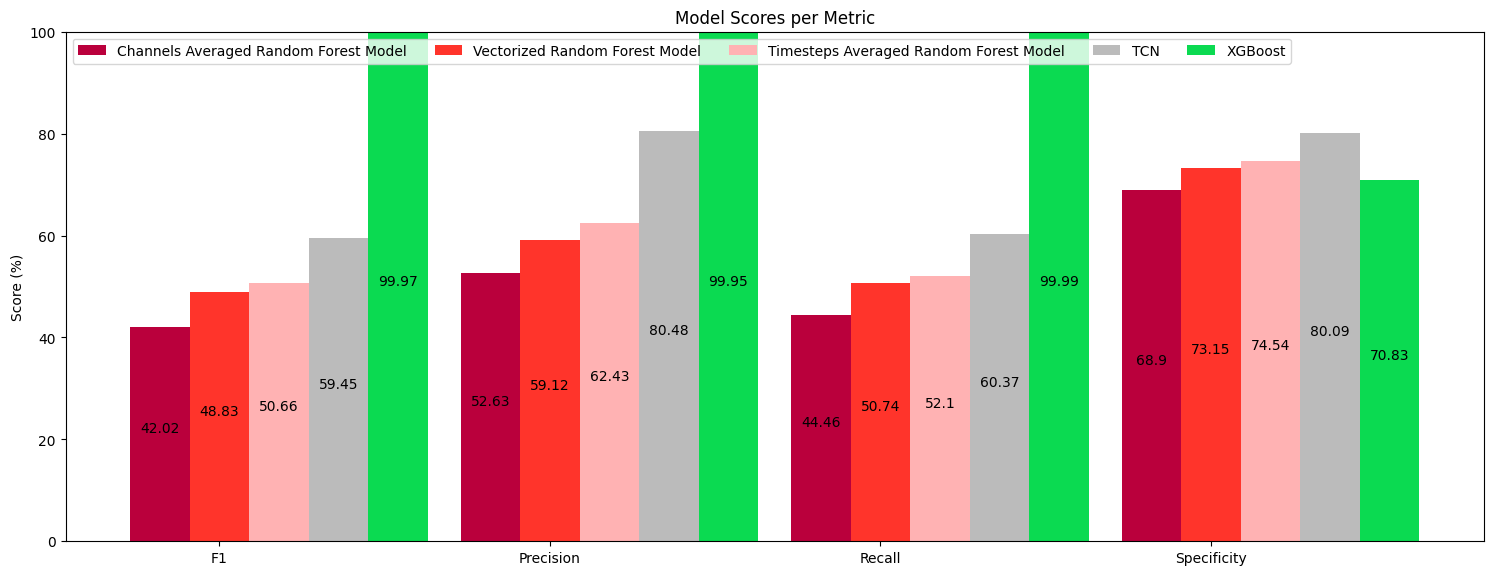

In [ ]:
import matplotlib.pyplot as plt

if 'metrics_1' not in vars() or 'metrics_2' not in vars() or 'metrics_3' not in vars() or 'model_1_name' not in vars() or 'model_2_name' not in vars() or 'model_3_name' not in vars() or 'xgboost_metrics' not in vars():
  model_1_name = "timesteps_averaged_random_forest_model"
  model_2_name = "channels_averaged_random_forest_model"
  model_3_name = "vectorized_random_forest_model"
  # Averaging over time steps and leaving each channel separate
  metrics_1 = {'f1': 0.5065541738217728, 'precision': 0.624327541037041, 'recall': 0.5209946396664681, 'specificity': 0.7454475855498239}
  # Averaging over channels and leaving each time step separate
  metrics_2 = {'f1': 0.4202044926277606, 'precision': 0.5263277706461394, 'recall': 0.4446098868374032, 'specificity': 0.6890244709914333}
  # Averaging over nothing and vectorizing input data
  metrics_3 = {'f1': 0.4882627632566844, 'precision': 0.5911645532914073, 'recall': 0.507395274965257, 'specificity': 0.731462583768323}
  tcn_metrics = {'f1': 0.5945, 'precision': 0.8048, 'recall': 0.6037, 'specificity': 0.8009}
  xgboost_metrics = {'f1': 0.9996644420416838, 'precision': 0.9994781182434951, 'recall': 0.9998508353221957, 'specificity': 0.7083333333333334}

# Derived from the default code for matplotlib plots: https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html

metrics = ("F1", "Precision", "Recall", "Specificity")

model_1_title_cleaned = model_1_name.replace("_"," ").title()
model_2_title_cleaned = model_2_name.replace("_"," ").title()
model_3_title_cleaned = model_3_name.replace("_"," ").title()

model_scores = {
  model_2_title_cleaned: (round(metrics_2['f1']*100, 2), round(metrics_2['precision']*100, 2), round(metrics_2['recall']*100, 2), round(metrics_2['specificity']*100, 2)),
  model_3_title_cleaned: (round(metrics_3['f1']*100, 2), round(metrics_3['precision']*100, 2), round(metrics_3['recall']*100, 2), round(metrics_3['specificity']*100, 2)),
  model_1_title_cleaned: (round(metrics_1['f1']*100, 2), round(metrics_1['precision']*100, 2), round(metrics_1['recall']*100, 2), round(metrics_1['specificity']*100, 2)),
  "TCN": (round(tcn_metrics['f1']*100, 2), round(tcn_metrics['precision']*100, 2), round(tcn_metrics['recall']*100, 2), round(tcn_metrics['specificity']*100, 2)),
  "XGBoost": (round(xgboost_metrics['f1']*100, 2), round(xgboost_metrics['precision']*100, 2), round(xgboost_metrics['recall']*100, 2), round(xgboost_metrics['specificity']*100, 2)),
}

x = np.arange(len(metrics))  # the label locations
width = 0.18  # the width of the bars
multiplier = 0
colors = ["#ba003c", "#ff342b","#ffb2b3", "#bbbbbb", "#0bda51"]

fig, ax = plt.subplots(layout='compressed', figsize = (7.41*2, 2.82*2))

for attribute, measurement in model_scores.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=colors[multiplier])
    ax.bar_label(rects, padding=4, label_type = "center")
    multiplier += 1

ax.set_ylabel('Score (%)')
ax.set_title('Model Scores per Metric')
ax.set_xticks(x + width, metrics)
ax.legend(loc='upper left', ncols=5)
ax.set_ylim(0, 100)
plt.show()

And in the following cell, an approach is taken where we make one model per channel and average their results.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
from numpy import load
import numpy as np

le = LabelEncoder()

X_transposed = np.transpose(X_raw, (0, 2, 1))
X_tensor = torch.tensor(X_transposed, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

# Separate out each channel into an array of matrices
X_train_channels = []
X_test_channels = []
for i in range(19):
  X_train_channels.append(X_train[:, i, :])
  X_test_channels.append(X_test[:, i, :])

# Define one model per channel
models = []
for i in range(19):
  models.append(RandomForestClassifier(max_depth = 4, random_state = 0))

# Fit one model per channel, iteratively
for i in tqdm(range(19)):
  models[i].fit(X_train_channels[i], y_train)
# Get model results across all individual models and then average them
predictions = models[0].predict(X_test_channels[0])
for i in tqdm(range(1, 19)):
  current_channel_predictions = models[i].predict(X_test_channels[i])
  predictions = np.vstack((predictions, current_channel_predictions))
overall_predictions = np.mean(predictions, axis = 0).reshape((-1,)).round()
print(f"overall predictions shape: {overall_predictions.shape}")
print(f"y_test shape: {y_test.shape}")

# Compare this to performance with an initial mean of all channels
reduced_X_train = np.mean(X_train, axis = 1)
reduced_X_test = np.mean(X_test, axis = 1)
random_forest_model = RandomForestClassifier(max_depth = 4, random_state = 0)
random_forest_model.fit(reduced_X_train, y_train)
initial_average_predictions = random_forest_model.predict(reduced_X_test)

## Train with Validation and Final Evaluation

* Re-instantiate the TCN model and optimizer to reset weights, then train for 5 epochs, printing validation loss and accuracy at each epoch.
* Report the evaluation metrics for the Training, Validation, and Test sets.

## Identify Subject Groups

Extract subject IDs from `y_labels` and count unique subjects.


In [ ]:
subject_ids = y_labels[:, 1]
unique_subjects = np.unique(subject_ids)
num_subjects = len(unique_subjects)

print(f"Total unique subjects: {num_subjects}")
print(f"Unique subject IDs: {unique_subjects}")

Total unique subjects: 97
Unique subject IDs: ['10' '10.0' '11' '11.0' '12' '12.0' '13' '13.0' '14' '14.0' '15' '15.0'
 '16' '16.0' '17' '17.0' '18' '18.0' '19' '19.0' '20' '20.0' '21' '21.0'
 '22' '22.0' '23' '23.0' '24' '25' '26' '27' '28' '29' '30' '31' '32' '33'
 '34' '35' '36' '37' '38' '39' '40' '41' '42' '43' '44' '45' '46' '47'
 '48' '49' '50' '51' '52' '53' '54' '55' '56' '57' '58' '59' '60' '61'
 '62' '63' '64' '65' '66' '67' '68' '69' '70' '71' '72' '73' '74' '75'
 '76' '77' '78' '79' '80' '81' '82' '83' '84' '85' '86' '87' '88' '89'
 '90' '91' '92']


In [ ]:
!ls -a sample_data/


.	       california_housing_test.csv   mnist_train_small.csv
..	       california_housing_train.csv  README.md
anscombe.json  mnist_test.csv


# XGBoost Model
Since the TCN has massive recall and specificity but has bad interpretability (CNNs are black box algorithms), we are interested in exploring more interpretable models

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# THIS TAKES 9-10 MINUTES TO RUN (ish) !!!!!

# We will reduce the 128 time-steps to N principal components per channel because time steps are less important to making decisions on this, according to earlier tests
n_components_per_channel = 10
pca = PCA(n_components=n_components_per_channel)

# X_raw is (Samples, Time, Channels) -> (101916, 128, 19)
num_samples, num_time, num_channels = X_raw.shape

# Array to hold the new features: (Samples, Channels * Components)
X_pca_features = np.zeros((num_samples, num_channels * n_components_per_channel))

print(f"Applying PCA to {num_channels} channels...")

for c in range(num_channels):
    # Extract data for one channel: (Samples, Time)
    channel_data = X_raw[:, :, c]

    # Fit and transform
    reduced_data = pca.fit_transform(channel_data)

    # Store in our feature matrix
    start_idx = c * n_components_per_channel
    end_idx = (c + 1) * n_components_per_channel
    X_pca_features[:, start_idx:end_idx] = reduced_data

# Create a DataFrame
column_names = [f'Ch{c+1}_PC{i+1}' for c in range(num_channels) for i in range(n_components_per_channel)]
df_pca = pd.DataFrame(X_pca_features, columns=column_names)

# Add the target labels (using the encoded version for the model)
df_pca['target'] = y_encoded

print("Tabularization complete.")
display(df_pca.head())
print(f"New DataFrame shape: {df_pca.shape}")

In [ ]:
import json
from sklearn.decomposition import PCA

pca_params = {}
num_channels = X_raw.shape[2]
n_components_per_channel = 10

print(f"Extracting PCA parameters for {num_channels} channels...")

for c in range(num_channels):
    pca = PCA(n_components=n_components_per_channel)
    channel_data = X_raw[:, :, c]
    pca.fit(channel_data)

    # Store components and mean as lists for JSON serialization
    pca_params[f'channel_{c+1}'] = {
        'components': pca.components_.tolist(),
        'mean': pca.mean_.tolist()
    }

# Save to JSON file
output_json_path = 'pca_parameters.json'
with open(output_json_path, 'w') as f:
    json.dump(pca_params, f)

print(f"Successfully saved PCA parameters to {output_json_path}")

In [ ]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Refine Labels: Binary Classification (Truly Healthy vs At Risk)
truly_healthy_ids = [89, 90, 91, 92]
subject_ids_int = np.array([get_clean_label(sid) for sid in y_labels[:, 1]])
is_truly_healthy = np.isin(subject_ids_int, truly_healthy_ids)

# Create binary targets: 0 = Truly Healthy, 1 = At Risk (any disease)
y_binary = np.zeros(len(y_encoded))
y_binary[~is_truly_healthy] = 1

# Filter to include only the 4 truly healthy vs the confirmed disease cases
mask = (is_truly_healthy) | (y_encoded > 0)
X_filtered = df_pca.drop('target', axis=1).values[mask]
y_filtered = y_binary[mask]

# 2. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

# 3. Calculate Class Weights for Binary
class_counts = np.bincount(y_train.astype(int))
total_samples = len(y_train)
weights = total_samples / (len(class_counts) * class_counts)
sample_weights = np.array([weights[int(t)] for t in y_train])

# 4. Custom Binary Weighted Loss. This sends the model to Hell if it gets a false positive and does a standard gradient descent on false negatives
def custom_binary_weighted_loss(preds, dtrain):
    labels = dtrain.get_label()
    # Convert raw logits to probabilities
    prob = 1.0 / (1.0 + np.exp(-preds))

    # Penalty for missing an 'At Risk' case
    fn_penalty = 10.0

    grad = prob - labels
    # Increase gradient and hessian for at-risk samples to prioritize recall
    grad[labels == 1] *= fn_penalty

    hess = prob * (1.0 - prob)
    hess[labels == 1] *= fn_penalty

    return grad, hess

# 5. Train
dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'max_depth': 6,
    'eta': 0.1,
    'objective': 'binary:logitraw', # Custom objective expects raw logits
    'eval_metric': 'logloss',
    'tree_method': 'hist',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Training Binary Model: Truly Healthy (n={len(truly_healthy_ids)}) vs At Risk (AD + Other)...")
bst = xgb.train(params, dtrain, num_boost_round=100, obj=custom_binary_weighted_loss)

# 6. Evaluate
raw_preds = bst.predict(dtest)
# Map logits to binary predictions
probs = 1.0 / (1.0 + np.exp(-raw_preds))
y_pred = (probs > 0.5).astype(int)

print("\n--- XGBoost Binary Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Truly Healthy', 'At Risk']))

cm = confusion_matrix(y_test, y_pred)
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall_at_risk = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp)
    xgb_f1 = (2*precision*recall_at_risk)/(precision + recall_at_risk)
    print(f"F1 Score: {xgb_f1}")
    print(f"Precision: {precision}")
    print(f"Recall (At Risk): {recall_at_risk}")
    print(f"Specificity (Truly Healthy): {spec}")

Training Binary Model: Truly Healthy (n=4) vs At Risk (AD + Other)...

--- XGBoost Binary Classification Report ---
               precision    recall  f1-score   support

Truly Healthy       0.89      0.71      0.79        24
      At Risk       1.00      1.00      1.00     13408

     accuracy                           1.00     13432
    macro avg       0.95      0.85      0.90     13432
 weighted avg       1.00      1.00      1.00     13432

F1 Score: 0.9996644420416838
Precision: 0.9994781182434951
Recall (At Risk): 0.9998508353221957
Specificity (Truly Healthy): 0.7083333333333334


In [ ]:
import xgboost as xgb
import onnxmltools
from sklearn.pipeline import Pipeline
from skl2onnx import to_onnx, update_registered_converter
from skl2onnx.common.data_types import FloatTensorType
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost as convert_xgboost_op
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
import os

# 1. Re-define the Pipeline
xgboost_model = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    objective='binary:logistic',
    tree_method='hist',
    random_state=42
)

pipe = Pipeline([
    ('pca', pca),
    ('xgboost', xgboost_model)
])

print("Fitting the integrated Pipeline...")
pipe.fit(X_filtered, y_filtered)

# 2. Register Converter with ZipMap AND nocl capability enabled
# 'nocl' is required by the internal shape calculator for linear classifiers
update_registered_converter(
    xgb.XGBClassifier, 'XGBoostXGBClassifier',
    calculate_linear_classifier_output_shapes, convert_xgboost_op,
    options={'zipmap': [True, False], 'nocl': [True, False]}
)

# 3. Convert: Pass options here to disable ZipMap for the specific 'xgboost' step
initial_type = [('input', FloatTensorType([None, X_filtered.shape[1]]))]
onnx_pipeline = to_onnx(
    pipe,
    initial_types=initial_type,
    target_opset={'': 12, 'ai.onnx.ml': 2},
    options={'xgboost': {'zipmap': False}}
)

# 4. Save
export_path = 'drive/MyDrive/SeniorDesign/exported_models/combined_pca_xgboost.onnx'
with open(export_path, "wb") as f:
    f.write(onnx_pipeline.SerializeToString())
    f.flush()
    os.fsync(f.fileno())

print(f"Success! Model re-exported to: {export_path}")

Fitting the integrated Pipeline...
Success! Model re-exported to: drive/MyDrive/SeniorDesign/exported_models/combined_pca_xgboost.onnx


In [ ]:
!pip install onnxruntime

### Model Parity Testing
This section verifies that the exported ONNX model produces the same results as the original scikit-learn pipeline.

In [ ]:
import os

# Diagnostic: Check the file size of the exported model
file_path = 'drive/MyDrive/SeniorDesign/exported_models/combined_pca_xgboost.onnx'
if os.path.exists(file_path):
    size = os.path.getsize(file_path)
    print(f"File exists: {file_path}")
    print(f"File size: {size / 1024:.2f} KB")
    if size == 0:
        print("ERROR: The file is empty (0 bytes).")
else:
    print(f"ERROR: File not found at {file_path}")

File exists: drive/MyDrive/SeniorDesign/exported_models/combined_pca_xgboost.onnx
File size: 123.69 KB


In [ ]:
import onnx
import onnxruntime as rt
import os
from skl2onnx.common.data_types import FloatTensorType

try:
    # 1. Re-generate the ONNX model object
    initial_type = [('input', FloatTensorType([None, X_filtered.shape[1]]))]
    onnx_model = to_onnx(
        pipe,
        initial_types=initial_type,
        target_opset={'': 15, 'ai.onnx.ml': 3}
    )

    # 2. Serialize and save with explicit integrity checks
    model_bytes = onnx_model.SerializeToString()

    with open(export_path, 'wb') as f:
        f.write(model_bytes)
        f.flush()
        os.fsync(f.fileno())

    print(f"Model written to {export_path}")

    # 3. Structural Validation using ONNX's built-in checker
    # This verifies the protobuf structure itself is valid
    loaded_model = onnx.load(export_path)
    onnx.checker.check_model(loaded_model)
    print("SUCCESS: Model structure verified by onnx.checker!")

    # 4. Runtime Validation
    test_sess = rt.InferenceSession(export_path, providers=['CPUExecutionProvider'])
    print("SUCCESS: Model successfully loaded into InferenceSession!")

except Exception as e:
    print(f"VALDIATION FAILED: {e}")
    if "parsing failed" in str(e).lower():
        print("\nTIP: If protobuf parsing fails, ensure your 'onnx' and 'protobuf' packages are compatible.")

Model written to drive/MyDrive/SeniorDesign/exported_models/combined_pca_xgboost.onnx
SUCCESS: Model structure verified by onnx.checker!
SUCCESS: Model successfully loaded into InferenceSession!


In [ ]:
import onnxruntime as rt
import numpy as np

# 1. Establishment of Baseline (Scikit-learn)
sklearn_probs = pipe.predict_proba(X_test)

# 2. Loading and Running ONNX Model
sess = rt.InferenceSession(export_path, providers=['CPUExecutionProvider'])
input_name = sess.get_inputs()[0].name
# The output for a classifier in ONNX typically contains both labels and probabilities
# We check the session output names
output_names = [out.name for out in sess.get_outputs()]

onnx_preds = sess.run(output_names, {input_name: X_test.astype(np.float32)})

# Onnxruntime usually returns a list of dictionaries for probabilities if ZipMap is used,
# or a tensor if ZipMap is False. Based on common skl2onnx behavior:
onnx_probs = onnx_preds[1]
if isinstance(onnx_probs, list):
    # Convert list of dicts to array if necessary
    onnx_probs = np.array([[d[0], d[1]] for d in onnx_probs])

# 3. Statistical Comparison
# Use np.allclose to handle minor floating-point differences
parity_success = np.allclose(sklearn_probs, onnx_probs, atol=1e-5)

print(f"Parity Check Success: {parity_success}")
if not parity_success:
    diff = np.abs(sklearn_probs - onnx_probs).max()
    print(f"Maximum probability difference: {diff}")
else:
    print("The ONNX model outputs match the scikit-learn pipeline outputs perfectly!")

Parity Check Success: False
Maximum probability difference: 0.0038436055183410645


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix

# Configuration
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

cv_results = []

print(f"Starting {k_folds}-Fold Cross Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_filtered, y_filtered)):
    # Split data
    X_cv_train, X_cv_val = X_filtered[train_idx], X_filtered[val_idx]
    y_cv_train, y_cv_val = y_filtered[train_idx], y_filtered[val_idx]

    # Calculate sample weights for this fold
    counts = np.bincount(y_cv_train.astype(int))
    fold_weights = len(y_cv_train) / (len(counts) * counts)
    fold_sample_weights = np.array([fold_weights[int(t)] for t in y_cv_train])

    # Prepare DMatrices
    dtrain_fold = xgb.DMatrix(X_cv_train, label=y_cv_train, weight=fold_sample_weights)
    dval_fold = xgb.DMatrix(X_cv_val, label=y_cv_val)

    # Train with custom loss
    bst_fold = xgb.train(params, dtrain_fold, num_boost_round=100, obj=custom_binary_weighted_loss)

    # Evaluate
    raw_preds = bst_fold.predict(dval_fold)
    probs = 1.0 / (1.0 + np.exp(-raw_preds))
    y_pred = (probs > 0.5).astype(int)

    # Calculate Metrics
    cm = confusion_matrix(y_cv_val, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)

        cv_results.append({'acc': accuracy, 'spec': specificity, 'rec': recall})
        print(f"Fold {fold+1}: Spec: {specificity:.4f}, Recall: {recall:.4f}")

# Summary
avg_spec = np.mean([r['spec'] for r in cv_results])
avg_rec = np.mean([r['rec'] for r in cv_results])
print(f"\n--- CV Results Summary ---")
print(f"Average Specificity (Truly Healthy): {avg_spec:.4f}")
print(f"Average Recall (At Risk): {avg_rec:.4f}")

Starting 5-Fold Cross Validation...


NameError: name 'X_filtered' is not defined

In [ ]:
# Ensure X_filtered and y_filtered are defined for Cross Validation
# Using the logic from cell lUeGjvbeyVJ2
truly_healthy_ids = [89, 90, 91, 92]
subject_ids_int = np.array([int(sid.split('.')[0]) for sid in y_labels[:, 1]])
is_truly_healthy = np.isin(subject_ids_int, truly_healthy_ids)

y_binary = np.zeros(len(y_encoded))
y_binary[~is_truly_healthy] = 1

mask = (is_truly_healthy) | (y_encoded > 0)
X_filtered = df_pca.drop('target', axis=1).values[mask]
y_filtered = y_binary[mask]

print(f"X_filtered shape: {X_filtered.shape}")
print(f"y_filtered shape: {y_filtered.shape}")

NameError: name 'df_pca' is not defined

# Task 1

In [ ]:
# Task 1 Graph
selected_channel = 0
healthy_subject_id = only_healthy_subjects[0]  # Assuming only_healthy_subjects is a list or array
ad_subject_id = unique_ad_subjects[0]       # Assuming unique_ad_subjects is an array

healthy_label_int = 0 # Corresponds to Healthy Control
ad_label_int = 1      # Corresponds to Alzheimer's Disease

print(f"Selected Channel: {selected_channel}")
print(f"Healthy Subject ID: {healthy_subject_id}")
print(f"AD Subject ID: {ad_subject_id}")
print(f"Healthy Label (int): {healthy_label_int}")
print(f"AD Label (int): {ad_label_int}")

In [ ]:
samples_to_extract = 10 # 10 seconds of data, assuming 1 sample = 1 second, though typically samples are shorter time segments

# Filter for Healthy Control subject's samples
healthy_subject_indices = np.where(
    (cleaned_labels == healthy_label_int) &
    (np.array([get_clean_label(sid) for sid in y_labels[:, 1]]) == healthy_subject_id)
)[0]

# Filter for AD subject's samples
ad_subject_indices = np.where(
    (cleaned_labels == ad_label_int) &
    (np.array([get_clean_label(sid) for sid in y_labels[:, 1]]) == ad_subject_id)
)[0]

# Extract and concatenate 10 samples for the selected channel
# Ensure there are enough samples available
healthy_eeg_data = X_raw[healthy_subject_indices[:samples_to_extract], :, selected_channel]
ad_eeg_data = X_raw[ad_subject_indices[:samples_to_extract], :, selected_channel]

# Concatenate the time points from the selected samples
healthy_eeg_concatenated = healthy_eeg_data.reshape(-1) # Flatten all time points
ad_eeg_concatenated = ad_eeg_data.reshape(-1) # Flatten all time points

print(f"Shape of concatenated Healthy EEG data: {healthy_eeg_concatenated.shape}")
print(f"Shape of concatenated AD EEG data: {ad_eeg_concatenated.shape}")


In [ ]:
import matplotlib.pyplot as plt

# Create a time axis for plotting
time_points_per_sample = X_raw.shape[1] # 128 time points per sample
time_axis_healthy = np.arange(len(healthy_eeg_concatenated)) / time_points_per_sample
time_axis_ad = np.arange(len(ad_eeg_concatenated)) / time_points_per_sample

plt.figure(figsize=(15, 6))
plt.plot(time_axis_healthy, healthy_eeg_concatenated, label=f'Healthy Subject {healthy_subject_id} (Channel {selected_channel})', alpha=0.7)
plt.plot(time_axis_ad, ad_eeg_concatenated, label=f'AD Subject {ad_subject_id} (Channel {selected_channel})', alpha=0.7)
plt.title(f'Concatenated EEG Signals (10 Samples) for Channel {selected_channel}')
plt.xlabel('Time (in samples of 128 time points)')
plt.ylabel('EEG Signal Amplitude')
plt.legend()
plt.grid(True)
plt.show()


# Task 2

In [ ]:
# HEALTHY PATIENTS TABLE
import numpy as np
from scipy import signal
from tabulate import tabulate

channel_names = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3/T7', 'C3', 'Cz', 'C4', 'T4/T8', 'T5/P7', 'P3', 'Pz', 'P4', 'T6/P8', 'O1', 'O2']

healthy_table = []
# idk what im doing so idk if this needs to be adjusted for this task
# currently it uses the 10 second samples like from task 1
# samples_to_extract = seconds here

for i in range(0,19):
  healthy_table_row = [channel_names[i]];
  selected_channel = i
  # Extract and concatenate 10 samples for the selected channel
  # Ensure there are enough samples available
  healthy_eeg_data = X_raw[healthy_subject_indices[:samples_to_extract], :, selected_channel]

  # Concatenate the time points from the selected samples
  healthy_eeg_concatenated = healthy_eeg_data.reshape(-1) # Flatten all time points

  # healthy
  fs = 128 # 128 hz
  healthy_f, healthy_Pxx_den = signal.welch(healthy_eeg_concatenated, fs, nperseg=1280)

  deltaband_indices = np.where((healthy_f >= 0) & (healthy_f < 4))
  deltaband_power = healthy_Pxx_den[deltaband_indices]
  average_delta_power = np.mean(deltaband_power)
  healthy_table_row.append(average_delta_power)

  thetaband_indices = np.where((healthy_f >= 4) & (healthy_f < 8))
  thetaband_power = healthy_Pxx_den[thetaband_indices]
  average_theta_power = np.mean(thetaband_power)
  healthy_table_row.append(average_theta_power)

  alphaband_indices = np.where((healthy_f >= 8) & (healthy_f < 13))
  alphaband_power = healthy_Pxx_den[alphaband_indices]
  average_alpha_power = np.mean(alphaband_power)
  healthy_table_row.append(average_alpha_power)

  betaband_indices = np.where((healthy_f >= 13) & (healthy_f < 30))
  betaband_power = healthy_Pxx_den[betaband_indices]
  average_beta_power = np.mean(betaband_power)
  healthy_table_row.append(average_beta_power)

  healthy_table.append(healthy_table_row)

# print table
print(f"HEALTHY SUBJECTS")
print(tabulate(healthy_table, headers=['Channel', 'Delta Power', 'Theta Power', 'Alpha Power', 'Beta Power']))


In [ ]:
## AD PATIENTS TABLE

import numpy as np
from scipy import signal
from tabulate import tabulate

ad_table = []
# samples_to_extract = seconds here

for i in range(0,19):
  ad_table_row = [channel_names[i]];
  selected_channel = i
  # Extract and concatenate 10 samples for the selected channel
  # Ensure there are enough samples available
  ad_eeg_data = X_raw[ad_subject_indices[:samples_to_extract], :, selected_channel]

  # Concatenate the time points from the selected samples
  ad_eeg_concatenated = ad_eeg_data.reshape(-1) # Flatten all time points

  # ad
  fs = 128 # 128 hz
  ad_f, ad_Pxx_den = signal.welch(ad_eeg_concatenated, fs, nperseg=1280)

  deltaband_indices = np.where((ad_f >= 0) & (ad_f < 4))
  deltaband_power = ad_Pxx_den[deltaband_indices]
  average_delta_power = np.mean(deltaband_power)
  ad_table_row.append(average_delta_power)

  thetaband_indices = np.where((ad_f >= 4) & (ad_f < 8))
  thetaband_power = ad_Pxx_den[thetaband_indices]
  average_theta_power = np.mean(thetaband_power)
  ad_table_row.append(average_theta_power)

  alphaband_indices = np.where((ad_f >= 8) & (ad_f < 13))
  alphaband_power = ad_Pxx_den[alphaband_indices]
  average_alpha_power = np.mean(alphaband_power)
  ad_table_row.append(average_alpha_power)

  betaband_indices = np.where((ad_f >= 13) & (ad_f < 30))
  betaband_power = ad_Pxx_den[betaband_indices]
  average_beta_power = np.mean(betaband_power)
  ad_table_row.append(average_beta_power)

  ad_table.append(ad_table_row)

# print table
print(f"ALZHEIMERS SUBJECTS")
print(tabulate(ad_table, headers=['Channel', 'Delta Power', 'Theta Power', 'Alpha Power', 'Beta Power']))


# Task 3


In [ ]:
import numpy as np
from scipy import signal

fs = 128
alpha_healthy = []
theta_healthy = []

for subject_idx in healthy_subject_indices:

    subject_data = X_raw[subject_idx, :, :]  # shape: time x channels

    # Example: average across all channels (recommended)
    subject_mean_signal = np.mean(subject_data, axis=1)

    f, Pxx = signal.welch(subject_mean_signal, fs, nperseg=1280)

    # Alpha band
    alpha_idx = np.where((f >= 8) & (f < 13))
    alpha_power = np.mean(Pxx[alpha_idx])

    # Theta band
    theta_idx = np.where((f >= 4) & (f < 8))
    theta_power = np.mean(Pxx[theta_idx])

    alpha_healthy.append(alpha_power)
    theta_healthy.append(theta_power)

In [ ]:
alpha_ad = []
theta_ad = []

for subject_idx in ad_subject_indices:

    subject_data = X_raw[subject_idx, :, :]
    subject_mean_signal = np.mean(subject_data, axis=1)

    f, Pxx = signal.welch(subject_mean_signal, fs, nperseg=1280)

    alpha_idx = np.where((f >= 8) & (f < 13))
    alpha_power = np.mean(Pxx[alpha_idx])

    theta_idx = np.where((f >= 4) & (f < 8))
    theta_power = np.mean(Pxx[theta_idx])

    alpha_ad.append(alpha_power)
    theta_ad.append(theta_power)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot([alpha_healthy, alpha_ad])
plt.xticks([1,2], ['Healthy', 'Alzheimer'])
plt.ylabel('Alpha Power')
plt.title('Alpha Power: Healthy vs Alzheimer')
plt.show()

In [ ]:
plt.figure()
plt.boxplot([theta_healthy, theta_ad])
plt.xticks([1,2], ['Healthy', 'Alzheimer'])
plt.ylabel('Theta Power')
plt.title('Theta Power: Healthy vs Alzheimer')
plt.show()

In [ ]:
mean_alpha_healthy = np.mean(alpha_healthy)
mean_alpha_ad = np.mean(alpha_ad)

mean_theta_healthy = np.mean(theta_healthy)
mean_theta_ad = np.mean(theta_ad)

print("Alpha Mean (Healthy):", mean_alpha_healthy)
print("Alpha Mean (AD):", mean_alpha_ad)

print("Theta Mean (Healthy):", mean_theta_healthy)
print("Theta Mean (AD):", mean_theta_ad)

In [ ]:
from scipy.stats import ttest_ind

t_alpha, p_alpha = ttest_ind(alpha_healthy, alpha_ad)
t_theta, p_theta = ttest_ind(theta_healthy, theta_ad)

print("Alpha p-value:", p_alpha)
print("Theta p-value:", p_theta)